# STAT 207 Homework 6 [25 points]

## Deeper Dive into Hypothesis Testing and Introduction to Linear Regression

Due: Thursday, October 17, end of day (11:59 pm CT)

<hr>

## Imports 

Run the following code cell to import the necessary packages into the file.  You may import additional packages, as needed for this assignment.

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## Case Study: County Housing Information

The provided **county.csv** file contains various statistics about the population of every county in the United States.  You can read more about this dataset and its variables here:

https://www.openintro.org/data/index.php?data=county

Observational Unit: Each row contains data recorded for a county

Variables: 

In question 1, we will focus on the `multi_unit` variable in the data, which reports the percent of housing units in each county that are in multi-unit structures (e.g. apartments).  In question 2, we will add the `homeownership` variable, which records the rate of home ownership.  

Below, we read in the data as `df` for later analysis.

In [152]:
df = pd.read_csv('county.csv', na_values = ['data unavailable'])
df

,name,state,pop2000,pop2010,pop2017,pop_change,poverty,homeownership,multi_unit,unemployment_rate,metro,median_edu,per_capita_income,median_hh_income,smoking_ban
0,Autauga County,Alabama,43671.0,54571,55504.0,1.48,13.7,77.5,7.2,3.86,yes,some_college,27841.70,55317.0,none
1,Baldwin County,Alabama,140415.0,182265,212628.0,9.19,11.8,76.7,22.6,3.99,yes,some_college,27779.85,52562.0,none
2,Barbour County,Alabama,29038.0,27457,25270.0,-6.22,27.2,68.0,11.1,5.90,no,hs_diploma,17891.73,33368.0,partial
3,Bibb County,Alabama,20826.0,22915,22668.0,0.73,15.2,82.9,6.6,4.39,yes,hs_diploma,20572.05,43404.0,none
4,Blount County,Alabama,51024.0,57322,58013.0,0.68,15.6,82.0,3.7,4.02,yes,hs_diploma,21367.39,47412.0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3137,Sweetwater County,Wyoming,37613.0,43806,43534.0,-3.57,12.0,73.7,14.6,4.55,no,some_college,30282.59,71083.0,none
3138,Teton County,Wyoming,18251.0,21294,23265.0,4.21,6.8,60.8,31.9,2.99,no,bachelors,48557.37,80049.0,partial
3139,Uinta County,Wyoming,19742.0,21118,20495.0,-2.22,14.9,73.7,17.0,4.50,no,some_college,27048.12,54672.0,none
3140,Washakie County,Wyoming,8289.0,8533,8064.0,-4.31,12.8,70.9,10.0,4.08,no,some_college,27494.83,51362.0,none


## 1. Deeper Dive Into p-Values and Significance Levels [5 points] 

**a)** Calculate the mean multi-unit housing rate for the data.

In [153]:
df['multi_unit'].mean()

12.321896880967534

**b)** We will start by creating a sampling distribution of the mean multi-unit housing rate for 5 randomly selected counties.  Record 5000 repetitions in your simulated sampling distribution.

array([[<Axes: title={'center': 'Multi_Unit_Mean'}>]], dtype=object)

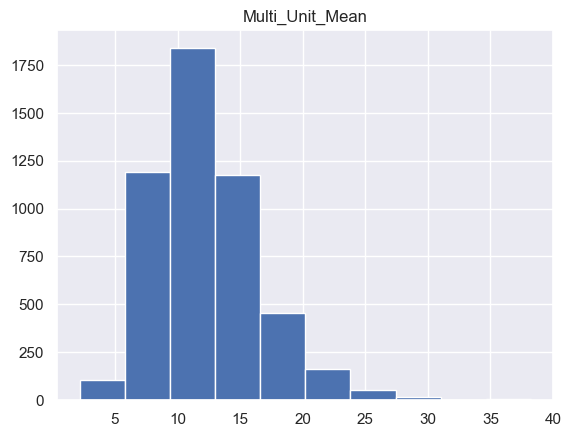

In [154]:
lst = []
for i in range(5000):
    sample = df.sample(5, replace=True)
    lst.append(sample['multi_unit'].mean())
MU_sample_dist = pd.DataFrame({'Multi_Unit_Mean':lst})
MU_sample_dist.hist()

**c)** Now, we will use the following hypotheses as the framework for our next parts:

$H_0: \mu = 12.32$

$H_a: \mu > 12.32$

First, take a random sample of size 5 from the population of counties **without replacement**.  Within the `sample` function, use the argument `random_state = 207`.  Using this random sample along with the sampling distribution from part **b**, calculate the p-value for the test above.

In [155]:
random_sample = df.sample(n=5, replace=False, random_state=207)
sample_mean = random_sample['multi_unit'].mean()
sample_mean

14.76

In [156]:
p_value = sum(MU_sample_dist['Multi_Unit_Mean'] >= sample_mean) / len(MU_sample_dist)
p_value

0.2374

**d)** Now, we'd like to explore the behavior of a p-value.  To do this, we will use many random samples of size 5 to calculate their corresponding p-values, repeating the process from **part c** many times.

For each of your random samples, be sure to save the p-value for future analysis.  Repeat this process 500 times with random samples of size 5 taken from the population without replacement.

In [157]:
p_values = []
for i in range(500):
    random_sample = df.sample(n=5, replace=False)
    sample_mean = random_sample['multi_unit'].mean()
    p_value = sum(MU_sample_dist['Multi_Unit_Mean'] >= sample_mean) / len(MU_sample_dist)
    p_values.append(p_value)
p_values_df = pd.DataFrame({'p_value': p_values})

array([[<Axes: title={'center': 'p_value'}>]], dtype=object)

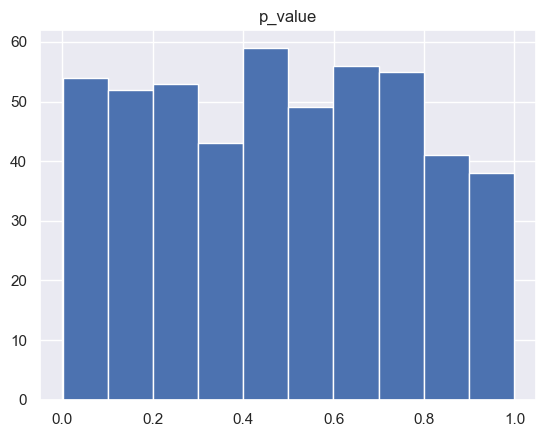

In [158]:
p_values_df.hist()

In [159]:
p_values_df

,p_value
0,0.7600
1,0.6326
2,0.5522
3,0.5496
4,0.8302
...,...
495,0.9656
496,0.5408
497,0.7408
498,0.6520


In [160]:
sum(p_values_df['p_value'] < 0.05) / len(p_values_df)

0.042

In [161]:
sum(p_values_df['p_value'] < 0.2) / len(p_values_df)

0.212

**e)** Finally, suppose that we consider Champaign and its four neighboring counties (Vermilion, Ford, Piatt, and Douglas) as a sample of counties from the US.  First, calculate the sample mean multi-unit rate of these five counties from Illinois.  Then, using your simulated sampling distribution, calculate the p-value based on these five counties.

**Tip**: You may want to review Homework 4.  We can use the **`&`** ("and") operator to indicate that we want **both** conditions on either side of the operator to be met.  We can use the `**|**` ("or") operator to indicate that we want **at least one** of the conditions to be met.  We can also chain these operators together if we need to represent more complex operations.

In [162]:
five_counties = df[(df['name'] == 'Champaign County') | (df['name'] == 'Vermilion County') | (df['name'] == 'Ford County') | (df['name'] == 'Piatt County') | (df['name'] == 'Douglas County')]
five_counties

,name,state,pop2000,pop2010,pop2017,pop_change,poverty,homeownership,multi_unit,unemployment_rate,metro,median_edu,per_capita_income,median_hh_income,smoking_ban
262,Douglas County,Colorado,175766.0,285465,335299.0,9.59,3.6,82.5,14.9,2.39,yes,bachelors,48499.64,111154.0,partial
434,Douglas County,Georgia,92174.0,132403,143882.0,5.67,14.2,71.5,16.1,4.89,yes,some_college,24947.04,59333.0,partial
604,Champaign County,Illinois,179669.0,201081,209399.0,1.83,21.4,55.9,35.2,4.24,yes,some_college,29619.49,49586.0,NaN
615,Douglas County,Illinois,19922.0,19980,19748.0,-0.57,12.1,78.3,11.2,4.01,no,hs_diploma,25796.91,52261.0,partial
621,Ford County,Illinois,14241.0,14081,13280.0,-2.86,15.7,79.1,7.9,4.70,yes,some_college,27234.78,50851.0,none
668,Piatt County,Illinois,16365.0,16729,16445.0,0.09,5.4,81.7,7.5,3.99,yes,some_college,33598.78,67360.0,NaN
686,Vermilion County,Illinois,83919.0,81625,77909.0,-3.31,19.8,71.3,14.5,6.29,yes,hs_diploma,23759.02,44930.0,NaN
910,Douglas County,Kansas,99962.0,110826,120793.0,5.45,18.7,53.5,32.0,3.16,yes,some_college,30301.65,54370.0,partial
916,Ford County,Kansas,32458.0,33848,34381.0,-1.59,16.2,68.3,18.6,2.79,no,hs_diploma,21602.33,49890.0,none
1334,Douglas County,Minnesota,32821.0,36009,37575.0,3.40,8.4,76.1,14.3,3.19,no,some_college,34052.89,58667.0,partial


In [165]:
sample_mean_5 = five_counties['multi_unit'].mean()
sample_mean_5

15.766666666666667

In [167]:
p_value_5_counties = sum(MU_sample_dist['Multi_Unit_Mean'] >= sample_mean_5) / len(MU_sample_dist)
p_value_5_counties

0.1758

## 2. Linear Regression [4 points]

How does the rate of homeownership affect the percent of housing units that are in multi-unit structures?

**a)** Generate a visualization to observe the relationship between the rate of homeownership and the percentage of multi-unit structure housing in the county.  Be sure to place each variable on the correct axes based on the underlying question above.

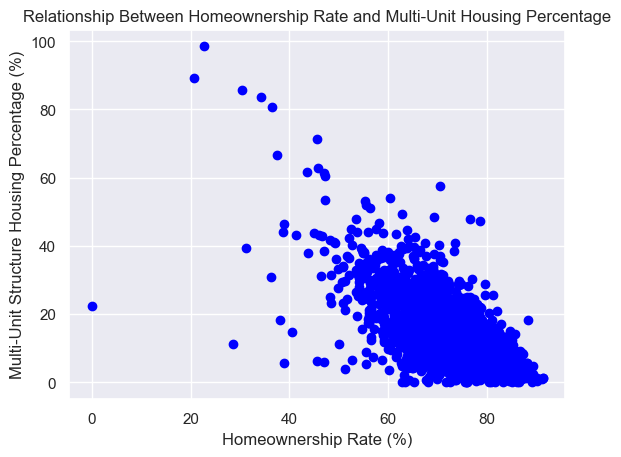

In [177]:
plt.scatter(df['homeownership'], df['multi_unit'], color='blue')
plt.title('Relationship Between Homeownership Rate and Multi-Unit Housing Percentage')
plt.xlabel('Homeownership Rate (%)')
plt.ylabel('Multi-Unit Structure Housing Percentage (%)')
plt.show()

**b)** Fit a linear model that predicts the `multi_unit` from `homeownership`.  Print the summary of the model.

In [188]:
import statsmodels.formula.api as smf
results = smf.ols('multi_unit ~ homeownership', data = df).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             multi_unit   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     2589.
Date:                Wed, 16 Oct 2024   Prob (F-statistic):               0.00
Time:                        22:03:04   Log-Likelihood:                -10516.
No. Observations:                3142   AIC:                         2.104e+04
Df Residuals:                    3140   BIC:                         2.105e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        70.7468      1.155     61.267      0.000      68.483      73.011
homeownership    -0.7974      0.016    -50.884      0.000      -0.828      -0.767
==============================================================================
Omnibus:                      695.956   Durbin-Watson:                   1.392
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4432.626
Skew:                           0.896   Prob(JB):                         0.00
Kurtosis:                       8.536   Cond. No.                         693.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [189]:
# multi_unit = 70.7468 - 0.7974 * homeownership

homeownership = 55.9

multi_unit = 70.7468 - 0.7974 * homeownership
multi_unit

26.17213999999999

In [190]:
# Residual = Observed Value - Predicted/Fitted Value

Observed = 35.2
Fitted = 26.17213999999999

Residual = Observed - Fitted
Residual

9.027860000000011

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 6 Canvas Assignment to submit your notebook to GitHub.